In [1]:
import numpy as np
import xarray as xr

In [2]:
import glob

In [3]:
from pathlib import Path

cwd = Path.cwd()
era5_dir = cwd.parents[6]

# build a path relative to two-up:
gh_dir = era5_dir / 'shared_data/Datasets/ERA5/plev'

In [4]:
ilev = 1000 # Pa

def pre(ds): return ds[['var129']].sel(lat=slice(-20,-90)).sel(plev=ilev)

In [5]:
mons = np.arange(7,12+1,1)

In [384]:
# for mon in mons:
# print(mon)
gh_fpath = str(gh_dir / f"era5_an_geopot_reg2_6h_*.nc")

gh_6h_mon = xr.open_mfdataset(gh_fpath, preprocess=pre, combine="by_coords", chunks="auto")
gh_6h_mon = gh_6h_mon.sel(time=slice('1984-06-01', '1984-06-30'))  # years 1979–2023

gh_day_mon = gh_6h_mon['var129'].resample(time="1D").mean()


In [385]:
gh_day_mon

<xarray.DataArray 'var129' (time: 30, lat: 36, lon: 180)> Size: 778kB
dask.array<transpose, shape=(30, 36, 180), dtype=float32, chunksize=(27, 36, 180), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * lat      (lat) float64 288B -20.0 -22.0 -24.0 -26.0 ... -86.0 -88.0 -90.0
    plev     float64 8B 1e+03
  * time     (time) datetime64[ns] 240B 1984-06-01 1984-06-02 ... 1984-06-30
Attributes:
    table:    128

In [386]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

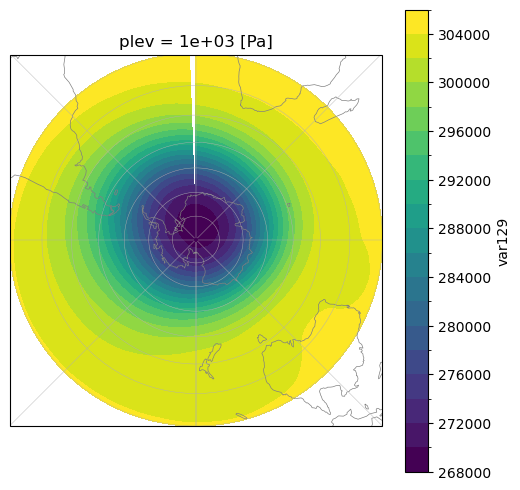

In [387]:
proj = ccrs.SouthPolarStereo()
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, -90, -20], ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="gray")
ax.gridlines(draw_labels=False, xlocs=np.arange(-180, 181, 45),
             ylocs=np.arange(-90, -19, 10), linewidth=0.3)

# filled contours
h = gh_day_mon.mean(dim='time').plot.contourf(ax=ax, transform=ccrs.PlateCarree(),
                     levels=21, add_colorbar=True)

In [388]:
np.sum(gh_day_mon[0]).values

array(1.8830633e+09, dtype=float32)

- open that of eunpa's

In [389]:
ep_z10 = xr.open_dataset('data/z10_eunpa/daily.z10.198406.nc')

In [390]:
np.sum(ep_z10['z'][0]).values

array(7.4279434e+09, dtype=float32)

In [391]:
gh_day_mon

<xarray.DataArray 'var129' (time: 30, lat: 36, lon: 180)> Size: 778kB
dask.array<transpose, shape=(30, 36, 180), dtype=float32, chunksize=(27, 36, 180), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * lat      (lat) float64 288B -20.0 -22.0 -24.0 -26.0 ... -86.0 -88.0 -90.0
    plev     float64 8B 1e+03
  * time     (time) datetime64[ns] 240B 1984-06-01 1984-06-02 ... 1984-06-30
Attributes:
    table:    128

In [392]:
gh_day_mon[0].sel(lon=slice(0,150)).values 

array([[304377.8 , 304362.06, 304355.06, ..., 303579.3 , 303588.56,
        303590.06],
       [304426.8 , 304392.8 , 304367.8 , ..., 303460.06, 303452.3 ,
        303455.06],
       [304491.06, 304446.3 , 304404.8 , ..., 303342.8 , 303329.8 ,
        303328.8 ],
       ...,
       [272166.56, 272188.3 , 272210.3 , ..., 273379.56, 273363.56,
        273346.3 ],
       [272166.3 , 272177.06, 272188.56, ..., 272723.56, 272716.56,
        272709.06],
       [272051.56, 272051.56, 272051.56, ..., 272051.56, 272051.56,
        272051.56]], dtype=float32)

In [393]:
da = ep_z10['z'][10]

In [394]:
da_sub = da.isel(
    latitude=slice(0, None, 2),
    longitude=slice(0, None, 2),
)

# 2) sort latitude (choose ascending or descending)
da_sub_asc  = da_sub.sortby('latitude', ascending=False)   # -90 → +90

In [395]:
diff = gh_day_mon[10].sel(lon=slice(0,150)).values -da_sub_asc.sel(longitude=slice(0,150))

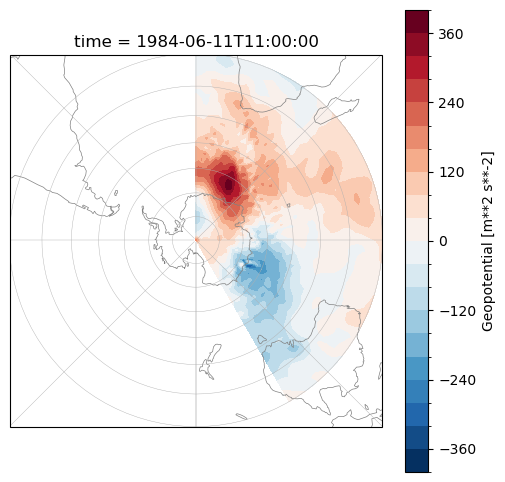

In [396]:
proj = ccrs.SouthPolarStereo()
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, -90, -20], ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="gray")
ax.gridlines(draw_labels=False, xlocs=np.arange(-180, 181, 45),
             ylocs=np.arange(-90, -19, 10), linewidth=0.3)

# filled contours
h = diff.plot.contourf(ax=ax, transform=ccrs.PlateCarree(),
                     levels=21, add_colorbar=True)

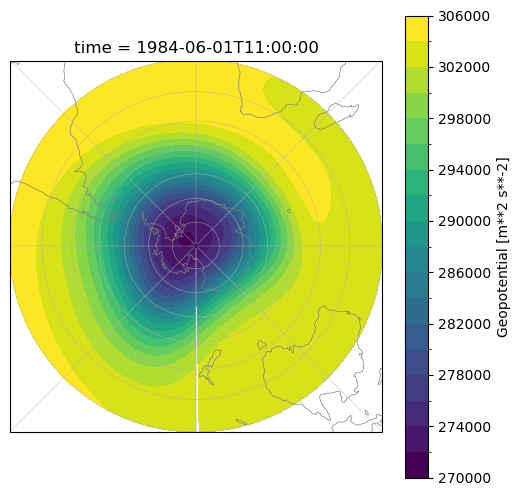

In [397]:
proj = ccrs.SouthPolarStereo()
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, -90, -20], ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="gray")
ax.gridlines(draw_labels=False, xlocs=np.arange(-180, 181, 45),
             ylocs=np.arange(-90, -19, 10), linewidth=0.3)

# filled contours
h = ep_z10['z'][0].plot.contourf(ax=ax, transform=ccrs.PlateCarree(),
                     levels=21, add_colorbar=True)

- toy model, just try to project

In [398]:
originaleof = 'data/zeof/ERA5.EOF1.z10.Mon06.nc'

In [399]:
oeof = xr.open_dataset(originaleof)

In [400]:
myeof = 'processed/zeof/ERA5.EOF1.z10.Mon06.nc'

In [401]:
meof = xr.open_dataset(myeof)

In [402]:
(da_sub_asc.values * meof['eof1']).sum(dim=['lat', 'lon']).values

array(9146008., dtype=float32)

In [403]:
(gh_day_mon[10] * meof['eof1']).sum(dim=['lat', 'lon']).values

array(9285943., dtype=float32)

In [404]:
da = ep_z10['z'][0]

In [405]:
da_sub = da.isel(
    latitude=slice(0, None, 2),
    longitude=slice(0, None, 2),
)

# 2) sort latitude (choose ascending or descending)
da_sub_asc  = da_sub.sortby('latitude', ascending=False)   # -90 → +90

In [406]:
(da_sub_asc.values * meof['eof1']).sum(dim=['lat', 'lon']).values

array(9138810., dtype=float32)

In [422]:
pc1_o = []
pc1_oo = []
for i in range(30):
    da = ep_z10['z'][i]

    da = da.assign_coords(longitude=(da.longitude % 360)).rename({'longitude': 'lon'}).sortby('lon')
    da  = da.sortby('latitude', ascending=False)   # -90 → +90
    da = da.rename({'latitude': 'lat'})

    
    da_sub = da.isel(
    lat=slice(0, None, 2),
    lon=slice(0, None, 2),
)
    # weights_o = np.cos(np.deg2rad(da_sub.lat))
    # pc1_o.append(da_sub.weighted(weights).sum(dim=['lat', 'lon']).values)

    # weights_oo = np.cos(np.deg2rad(da.lat))
    # pc1_oo.append(da.weighted(weights_oo).sum(dim=['lat', 'lon']).values)

    pc1_o.append((da_sub * weights).sum(dim=['lat', 'lon']).values)
    pc1_oo.append((da * weights_oo).sum(dim=['lat', 'lon']).values)
    
    # pc1_o.append((da_sub * meof['eof1']).sum(dim=['lat', 'lon']).values)
    # pc1_oo.append((da * oeof['eof1']).sum(dim=['lat', 'lon']).values)

In [348]:
import numpy as np

R = 6371000.0  # Earth radius [m]

pc1_o  = []  # integral on 2°×2° sub-sampled grid
pc1_oo = []  # integral on original 1°×1° grid

for i in range(30):
    da = ep_z10['z'][i]

    # normalize coords & sort
    da = (da.assign_coords(longitude=(da.longitude % 360))
             .rename({'longitude': 'lon', 'latitude': 'lat'})
             .sortby('lon')
             .sortby('lat'))  # ascending -90->90

    # --- sub-sample every other grid point (2° approx) ---
    da_sub = da.isel(lat=slice(0, None, 2), lon=slice(0, None, 2))

    # ---- cell-area weights for the *subsampled* grid ----
    dlat_deg_sub = np.abs(np.gradient(da_sub.lat.values)).mean()
    dlon_deg_sub = np.abs(np.gradient(da_sub.lon.values)).mean()
    dlat_sub = np.deg2rad(dlat_deg_sub)
    dlon_sub = np.deg2rad(dlon_deg_sub)
    phi_sub  = np.deg2rad(da_sub.lat)

    # exact spherical band formula for latitude strip
    band_sub = np.sin(phi_sub + dlat_sub/2) - np.sin(phi_sub - dlat_sub/2)
    cell_area_sub = (R**2) * dlon_sub * band_sub
    cell_area_sub = cell_area_sub.broadcast_like(da_sub)

    # resolution-invariant integral on subsampled grid
    pc1_o.append(((da_sub * cell_area_sub* meof['eof1']).sum(dim=['lat', 'lon'])).item())

    # ---- cell-area weights for the *original* grid ----
    dlat_deg = np.abs(np.gradient(da.lat.values)).mean()
    dlon_deg = np.abs(np.gradient(da.lon.values)).mean()
    dlat = np.deg2rad(dlat_deg)
    dlon = np.deg2rad(dlon_deg)
    phi  = np.deg2rad(da.lat)

    band = np.sin(phi + dlat/2) - np.sin(phi - dlat/2)
    cell_area = (R**2) * dlon * band
    cell_area = cell_area.broadcast_like(da)

    # resolution-invariant integral on original grid
    pc1_oo.append(((da * cell_area* oeof['eof1']).sum(dim=['lat', 'lon'])).item())


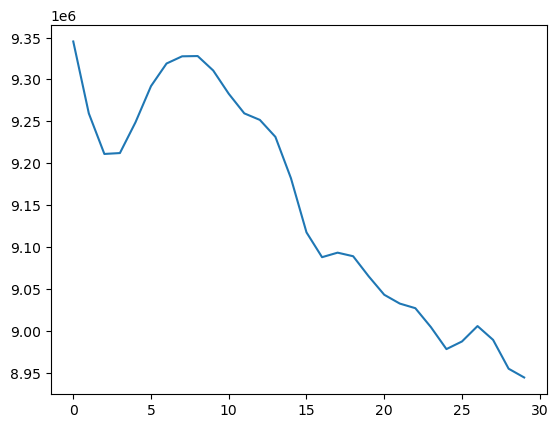

In [408]:
plt.plot(pc1_o)

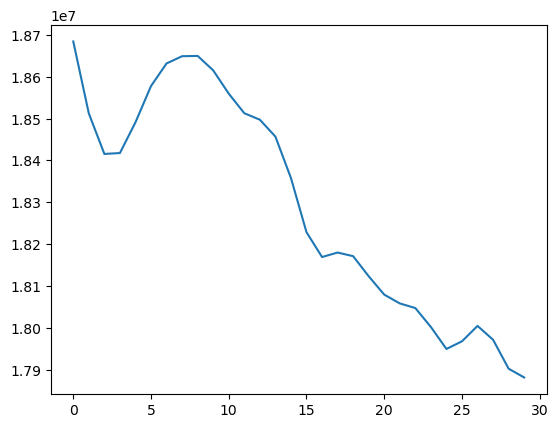

In [409]:
plt.plot(pc1_oo)


In [423]:
np.array(pc1_o)/np.array(pc1_oo)

array([0.2531369 , 0.2531396 , 0.25314143, 0.2531429 , 0.25314403,
       0.25314537, 0.2531465 , 0.253148  , 0.25314915, 0.25314984,
       0.25315005, 0.25315028, 0.253151  , 0.25315186, 0.25315276,
       0.2531534 , 0.25315398, 0.25315496, 0.25315624, 0.25315738,
       0.25315908, 0.25316024, 0.25316134, 0.25316158, 0.25316125,
       0.25315922, 0.25315708, 0.25315568, 0.25315413, 0.25315356],
      dtype=float32)

In [411]:
np.array(pc1_m)/np.array(pc1_mo)

array([1.9990816, 1.9990749, 1.9990724, 1.9990792, 1.9990869, 1.9990822,
       1.9990681, 1.9990621, 1.9990643, 1.9990636, 1.9990479, 1.9990354,
       1.9990184, 1.9989926, 1.9989693, 1.99896  , 1.9989523, 1.9989487,
       1.998945 , 1.9989432, 1.9989451, 1.9989522, 1.9989657, 1.998985 ,
       1.998999 , 1.9989978, 1.9989883, 1.998995 , 1.9990207, 1.9990436],
      dtype=float32)

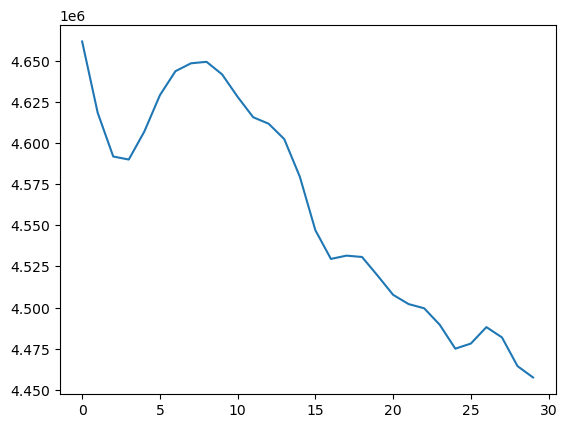

In [418]:
plt.plot(pc1_mo)

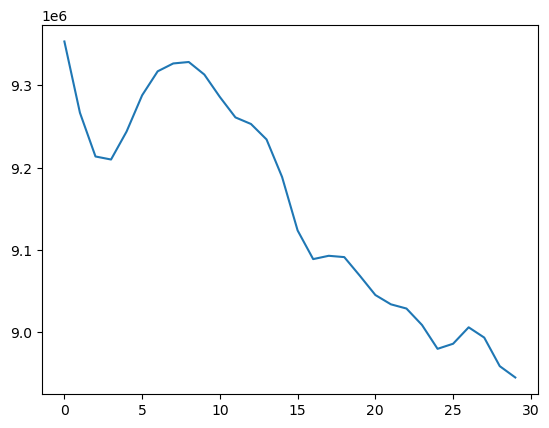

In [419]:
plt.plot(pc1_m)

In [364]:
np.array(pc1_m)/np.array(pc1_mo)

array([1.9990816, 1.9990749, 1.9990724, 1.9990792, 1.9990869, 1.9990822,
       1.9990681, 1.9990621, 1.9990643, 1.9990636, 1.9990479, 1.9990354,
       1.9990184, 1.9989926, 1.9989693, 1.99896  , 1.9989523, 1.9989487,
       1.998945 , 1.9989432, 1.9989451, 1.9989522, 1.9989657, 1.998985 ,
       1.998999 , 1.9989978, 1.9989883, 1.998995 , 1.9990207, 1.9990436],
      dtype=float32)

In [362]:
gh_day_mon[i]

<xarray.DataArray 'var129' (lat: 36, lon: 180)> Size: 26kB
dask.array<getitem, shape=(36, 180), dtype=float32, chunksize=(36, 180), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * lat      (lat) float64 288B -20.0 -22.0 -24.0 -26.0 ... -86.0 -88.0 -90.0
    plev     float64 8B 1e+03
    time     datetime64[ns] 8B 1985-06-30
Attributes:
    table:    128

In [417]:
pc1_m = []

pc1_mo = []

for i in range(30):

    # pc1_m.append((gh_day_mon[i] ).sum(dim=['lat', 'lon']).values)

    # pc1_mo.append((gh_day_mon[i] ).sum(dim=['lat', 'lon']).values)
    
    pc1_m.append((gh_day_mon[i] * meof['eof1']).sum(dim=['lat', 'lon']).values)

    pc1_mo.append((gh_day_mon[i] * reduce_oeof).sum(dim=['lat', 'lon']).values)

In [375]:
meof['eof1']

<xarray.DataArray 'eof1' (lat: 36, lon: 180)> Size: 26kB
array([[-4.780124e-03, -4.781740e-03, -4.785202e-03, ..., -4.776571e-03,
        -4.777769e-03, -4.779816e-03],
       [-4.746303e-03, -4.742365e-03, -4.745966e-03, ..., -4.732139e-03,
        -4.737217e-03, -4.745656e-03],
       [-4.693136e-03, -4.688818e-03, -4.690604e-03, ..., -4.662489e-03,
        -4.672332e-03, -4.687243e-03],
       ...,
       [ 6.226410e-03,  6.261592e-03,  6.297986e-03, ...,  6.128585e-03,
         6.159903e-03,  6.192504e-03],
       [ 4.700112e-03,  4.713144e-03,  4.726627e-03, ...,  4.663624e-03,
         4.675334e-03,  4.687505e-03],
       [ 1.964742e-10,  1.964742e-10,  1.964742e-10, ...,  1.964742e-10,
         1.964742e-10,  1.964742e-10]], dtype=float32)
Coordinates:
    mode     int64 8B ...
  * lat      (lat) float64 288B -20.0 -22.0 -24.0 -26.0 ... -86.0 -88.0 -90.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0

In [291]:
oeof

<xarray.Dataset> Size: 104kB
Dimensions:  (lat: 71, lon: 360)
Coordinates:
  * lat      (lat) float32 284B -90.0 -89.0 -88.0 -87.0 ... -22.0 -21.0 -20.0
  * lon      (lon) float32 1kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
Data variables:
    eof1     (lat, lon) float32 102kB ...

In [416]:
reduce_oeof = oeof['eof1'].isel(
    lat=slice(0, None, 2),
    lon=slice(0, None, 2),
)

In [166]:
test_my = gh_day_mon.sel(lat=-60, lon=150)

In [167]:
test = []
for i in range(30):
    da = ep_z10['z'][i]

    da_sub = da.isel(
    latitude=slice(0, None, 2),
    longitude=slice(0, None, 2),
)
    
    # 2) sort latitude (choose ascending or descending)
    da_sub_asc  = da_sub.sortby('latitude', ascending=False)   # -90 → +90
    test.append(da_sub_asc.sel(latitude=-60, longitude=150).values)

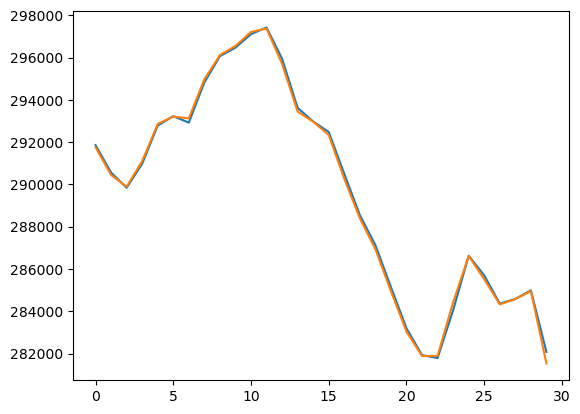

In [168]:
plt.plot(test_my)
plt.plot(np.array(test))

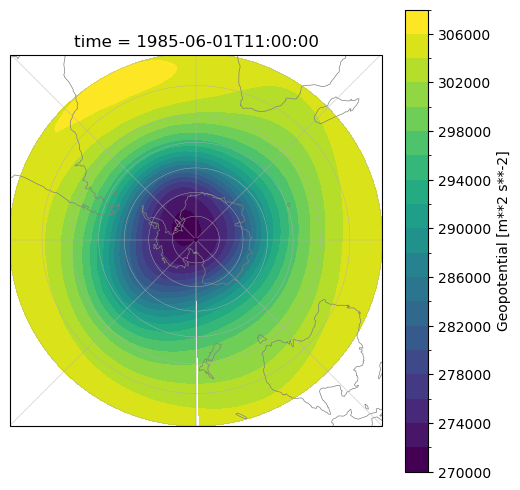

In [169]:
proj = ccrs.SouthPolarStereo()
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, -90, -20], ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="gray")
ax.gridlines(draw_labels=False, xlocs=np.arange(-180, 181, 45),
             ylocs=np.arange(-90, -19, 10), linewidth=0.3)

# filled contours
h = ep_z10['z'][0].plot.contourf(ax=ax, transform=ccrs.PlateCarree(),
                     levels=21, add_colorbar=True)

In [172]:
ep_z10['z'][0]

<xarray.DataArray 'z' (latitude: 71, longitude: 360)> Size: 102kB
[25560 values with dtype=float32]
Coordinates:
    time       datetime64[ns] 8B 1985-06-01T11:00:00
  * latitude   (latitude) float32 284B -90.0 -89.0 -88.0 ... -22.0 -21.0 -20.0
  * longitude  (longitude) float32 1kB -180.0 -179.0 -178.0 ... 178.0 179.0
Attributes:
    runave_op_ncl:  runave_n: nave=24
    level:          10
    units:          m**2 s**-2
    long_name:      Geopotential
    standard_name:  geopotential

In [175]:
da2 = da_sub.assign_coords(longitude=(da_sub.longitude % 360)).rename({'longitude': 'lon'}).sortby('lon')

In [177]:
da2.rename({'latitude':'lat'})

<xarray.DataArray 'z' (lat: 36, lon: 180)> Size: 26kB
array([[271808.34, 271808.34, 271808.34, ..., 271808.34, 271808.34, 271808.34],
       [271590.84, 271600.97, 271611.38, ..., 271561.94, 271571.25, 271581.06],
       [271527.84, 271550.25, 271573.06, ..., 271465.97, 271485.72, 271506.34],
       ...,
       [305807.6 , 305727.56, 305638.06, ..., 305989.47, 305936.56, 305876.2 ],
       [305797.84, 305731.75, 305660.2 , ..., 305943.22, 305902.25, 305854.44],
       [305731.47, 305677.8 , 305620.12, ..., 305847.2 , 305815.2 , 305776.84]],
      dtype=float32)
Coordinates:
    time     datetime64[ns] 8B 1985-06-01T11:00:00
  * lat      (lat) float32 144B -90.0 -88.0 -86.0 -84.0 ... -24.0 -22.0 -20.0
  * lon      (lon) float32 720B 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Attributes:
    runave_op_ncl:  runave_n: nave=24
    level:          10
    units:          m**2 s**-2
    long_name:      Geopotential
    standard_name:  geopotential

In [199]:
da

<xarray.DataArray 'z' (latitude: 71, longitude: 360)> Size: 102kB
[25560 values with dtype=float32]
Coordinates:
    time       datetime64[ns] 8B 1985-06-01T11:00:00
  * latitude   (latitude) float32 284B -90.0 -89.0 -88.0 ... -22.0 -21.0 -20.0
  * longitude  (longitude) float32 1kB -180.0 -179.0 -178.0 ... 178.0 179.0
Attributes:
    runave_op_ncl:  runave_n: nave=24
    level:          10
    units:          m**2 s**-2
    long_name:      Geopotential
    standard_name:  geopotential

In [197]:
da[0][0].values

array(271808.34, dtype=float32)

In [213]:
meof['eof1'].sel(lat=-60,lon=150).values

array(0.02917657, dtype=float32)

In [215]:
gh_day_mon.sel(lat=-60,lon=150).values*meof['eof1'].sel(lat=-60,lon=150).values

array([8515.425 , 8477.614 , 8456.603 , 8489.668 , 8542.287 , 8555.301 ,
       8546.444 , 8601.888 , 8638.111 , 8649.856 , 8668.499 , 8677.717 ,
       8634.57  , 8566.768 , 8547.958 , 8533.526 , 8475.69  , 8418.864 ,
       8377.427 , 8319.527 , 8262.661 , 8225.61  , 8221.665 , 8287.533 ,
       8362.778 , 8335.6455, 8296.715 , 8303.145 , 8315.035 , 8230.081 ],
      dtype=float32)

In [216]:
ep_z10['z'].sel(latitude=-60,longitude=150).values*meof['eof1'].sel(lat=-60,lon=150).values

array([8512.558, 8474.201, 8458.034, 8493.354, 8544.626, 8554.793,
       8552.337, 8606.203, 8639.682, 8652.223, 8671.65 , 8676.142,
       8627.294, 8561.571, 8547.652, 8529.307, 8468.809, 8414.433,
       8371.711, 8313.859, 8258.052, 8224.412, 8224.629, 8298.784,
       8362.339, 8330.374, 8295.702, 8303.017, 8313.978, 8214.131],
      dtype=float32)

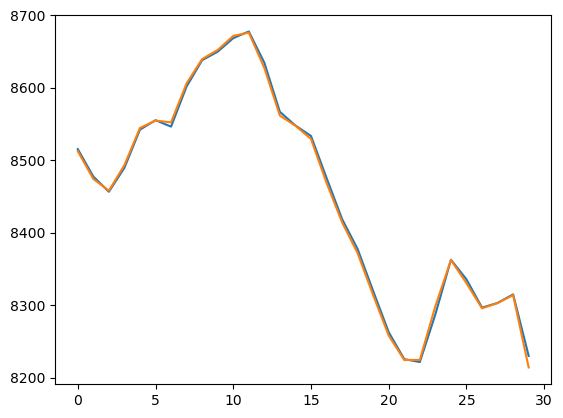

In [214]:
plt.plot(gh_day_mon.sel(lat=-60,lon=150).values*meof['eof1'].sel(lat=-60,lon=150).values)
plt.plot(ep_z10['z'].sel(latitude=-60,longitude=150).values*meof['eof1'].sel(lat=-60,lon=150).values)

In [178]:
da = ep_z10['z'][0]

da_sub = da.isel(
latitude=slice(0, None, 2),
longitude=slice(0, None, 2),
)

da2 = da_sub.assign_coords(longitude=(da_sub.longitude % 360)).rename({'longitude': 'lon'}).sortby('lon')
da2 = da2.rename({'latitude':'lat'})

In [192]:
gh_day_mon[0]

<xarray.DataArray 'var129' (lat: 36, lon: 180)> Size: 26kB
dask.array<getitem, shape=(36, 180), dtype=float32, chunksize=(36, 180), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * lat      (lat) float64 288B -20.0 -22.0 -24.0 -26.0 ... -86.0 -88.0 -90.0
    plev     float64 8B 1e+03
    time     datetime64[ns] 8B 1985-06-01
Attributes:
    table:    128

In [193]:
da2

<xarray.DataArray 'z' (lat: 36, lon: 180)> Size: 26kB
[6480 values with dtype=float32]
Coordinates:
    time     datetime64[ns] 8B 1985-06-01T11:00:00
  * lat      (lat) float32 144B -90.0 -88.0 -86.0 -84.0 ... -24.0 -22.0 -20.0
  * lon      (lon) float32 720B 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Attributes:
    runave_op_ncl:  runave_n: nave=24
    level:          10
    units:          m**2 s**-2
    long_name:      Geopotential
    standard_name:  geopotential

In [182]:
diff=gh_day_mon[0]-da2

In [191]:
gh_day_mon[0][0][0].values

array(305756.28, dtype=float32)

In [189]:
da2[0][0].values

array(271808.34, dtype=float32)

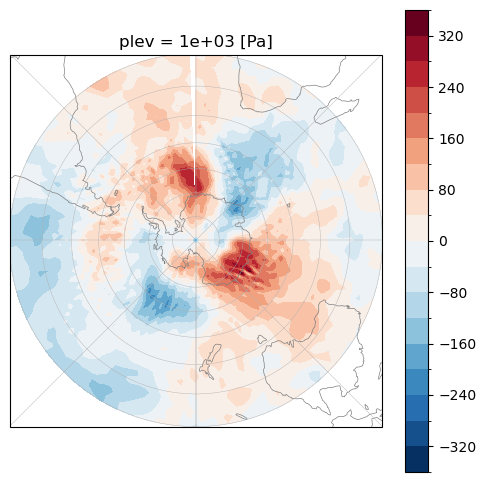

In [183]:
proj = ccrs.SouthPolarStereo()
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, -90, -20], ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="gray")
ax.gridlines(draw_labels=False, xlocs=np.arange(-180, 181, 45),
             ylocs=np.arange(-90, -19, 10), linewidth=0.3)

# filled contours
h = diff.plot.contourf(ax=ax, transform=ccrs.PlateCarree(),
                     levels=21, add_colorbar=True)